In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
titanic = pd.read_csv("D:\\project\\Github_repository\\titanic-survival-classification\\titanic-survival-classification\\src\\titanic.csv")
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [65]:
titanic.shape

(1310, 14)

In [66]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1310 entries, 0 to 1309
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   float64
 1   survived   1309 non-null   float64
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   float64
 6   parch      1309 non-null   float64
 7   ticket     1309 non-null   str    
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    str    
 10  embarked   1307 non-null   str    
 11  boat       486 non-null    str    
 12  body       121 non-null    float64
 13  home.dest  745 non-null    str    
dtypes: float64(7), str(7)
memory usage: 210.9 KB


In [67]:
titanic.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [68]:
print(f"unique : {titanic['survived'].unique()}")
print(f"Quantity of null: {titanic['survived'].isna().sum()}")
print(f"index null number: {titanic[titanic['survived'].isna()].index}")
print(f"Quantity of survived: {titanic[titanic['survived'] == 1].value_counts()}")
print(f"Quantity of Drowning: {titanic[titanic['survived'] == 0].value_counts()}")

unique : [ 1.  0. nan]
Quantity of null: 1
index null number: RangeIndex(start=1309, stop=1310, step=1)
Quantity of survived: Series([], Name: count, dtype: int64)
Quantity of Drowning: Series([], Name: count, dtype: int64)


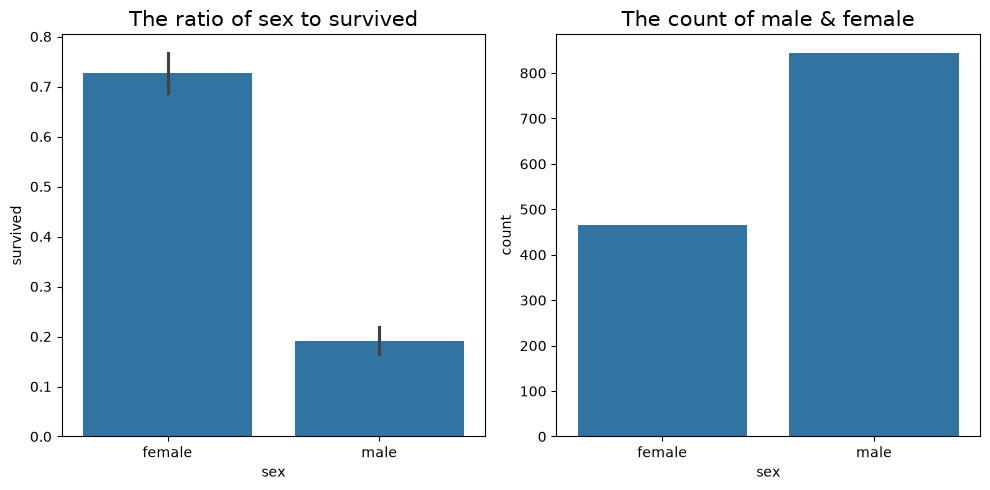

In [69]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(data=titanic, x='sex', y='survived', ax=axs[0])
axs[0].set_title('The ratio of sex to survived', size=15)

sns.countplot(data=titanic, x='sex', ax=axs[1])
axs[1].set_title('The count of male & female', size=15)

fig.tight_layout()

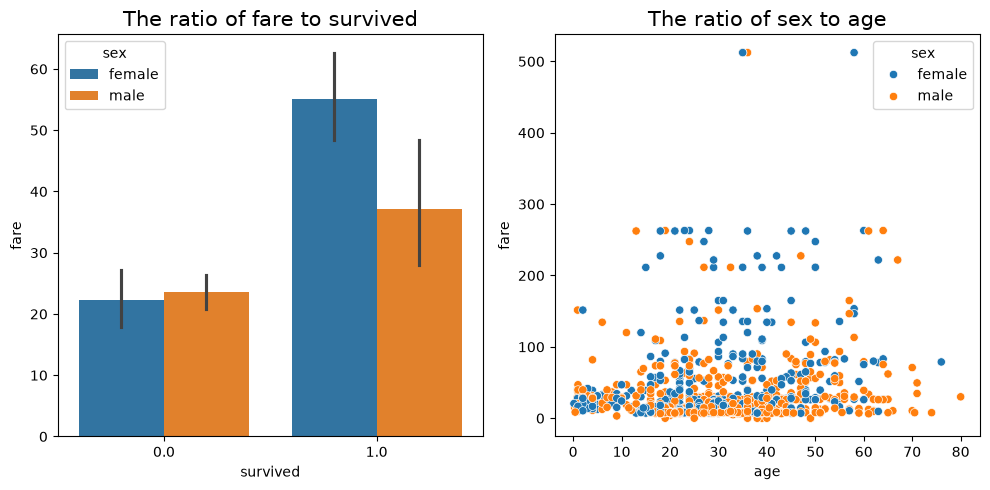

In [70]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(data=titanic, x='survived', y='fare', hue='sex', ax=axs[0])
axs[0].set_title('The ratio of fare to survived', size=15)

sns.scatterplot(data=titanic, x='age', y='fare', hue='sex', ax=axs[1])
axs[1].set_title('The ratio of sex to age', size=15)

fig.tight_layout()

In [71]:
titanic['ticket'].value_counts()

ticket
CA. 2343        11
1601             8
CA 2144          8
PC 17608         7
S.O.C. 14879     7
                ..
2628             1
2647             1
2656             1
2670             1
315082           1
Name: count, Length: 929, dtype: int64

In [72]:
titanic.iloc[1309]

pclass       NaN
survived     NaN
name         NaN
sex          NaN
age          NaN
sibsp        NaN
parch        NaN
ticket       NaN
fare         NaN
cabin        NaN
embarked     NaN
boat         NaN
body         NaN
home.dest    NaN
Name: 1309, dtype: object

In [73]:
titanic = titanic.drop(titanic.index[1309])

In [74]:
titanic.isna().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

<Axes: >

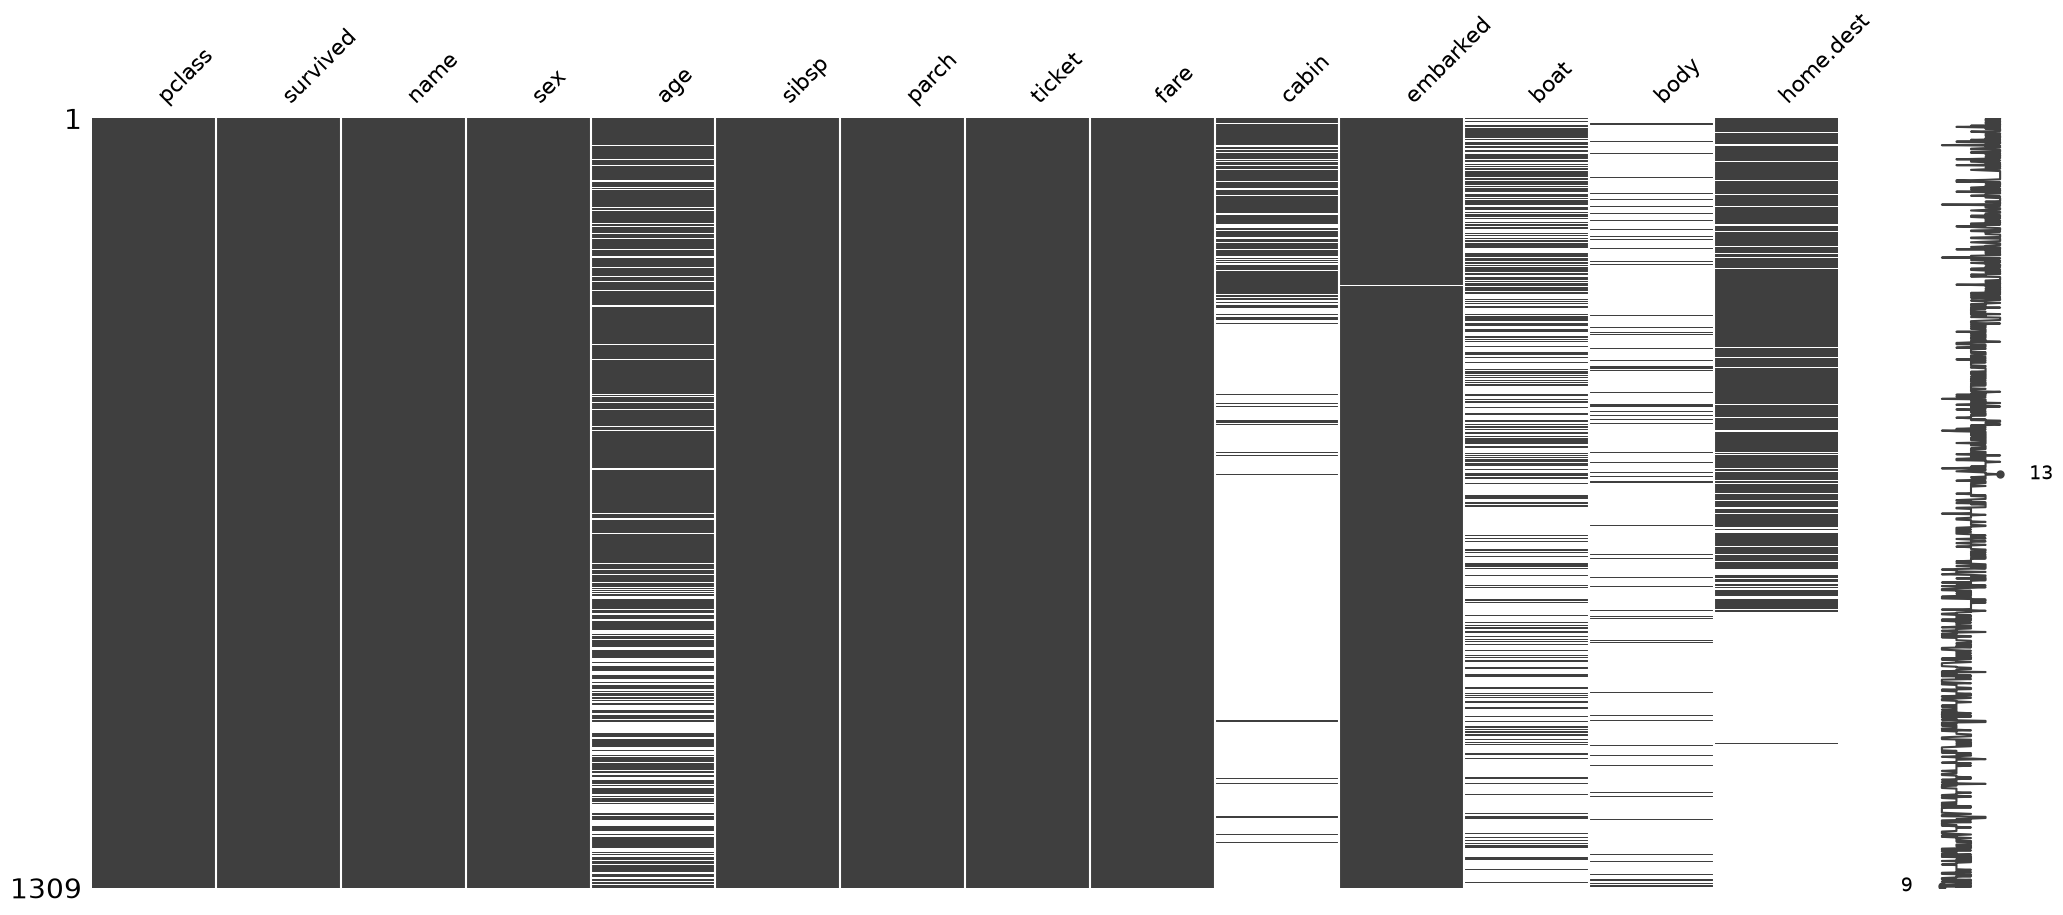

In [75]:
import missingno as msno

msno.matrix(titanic)

In [76]:
titanic['cabin'].value_counts().sum()

np.int64(295)

In [77]:
def drop_missing_columns(df, threshold=50):
    dropped_columns = []

    for col in df.columns:
        if df[col].isnull().mean() * 100 > threshold:
            dropped_columns.append(col)
            df.drop(columns =col, inplace=True)

    return dropped_columns

drop_missing_columns(titanic)

['cabin', 'boat', 'body']

In [78]:
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,S,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,0.0,"Zabour, Miss. Hileni",female,14.5000,1.0,0.0,2665,14.4542,C,NaN
1305,3.0,0.0,"Zabour, Miss. Thamine",female,NaN,1.0,0.0,2665,14.4542,C,NaN
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.5000,0.0,0.0,2656,7.2250,C,NaN
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0000,0.0,0.0,2670,7.2250,C,NaN


In [79]:
titanic.isna().sum()

pclass         0
survived       0
name           0
sex            0
age          263
sibsp          0
parch          0
ticket         0
fare           1
embarked       2
home.dest    564
dtype: int64

In [80]:
titanic['fare'] = titanic['fare'].fillna(titanic['fare'].median())

In [81]:
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic['embarked'].isna().sum()

np.int64(0)

In [82]:
titanic['age']

0       29.0000
1        0.9167
2        2.0000
3       30.0000
4       25.0000
         ...   
1304    14.5000
1305        NaN
1306    26.5000
1307    27.0000
1308    29.0000
Name: age, Length: 1309, dtype: float64

In [83]:
titanic['age'] = titanic['age'].interpolate(method='polynomial', order=2)

In [84]:
titanic['age'] = titanic['age'].round()
titanic['age']

0       29.0
1        1.0
2        2.0
3       30.0
4       25.0
        ... 
1304    14.0
1305    18.0
1306    26.0
1307    27.0
1308    29.0
Name: age, Length: 1309, dtype: float64

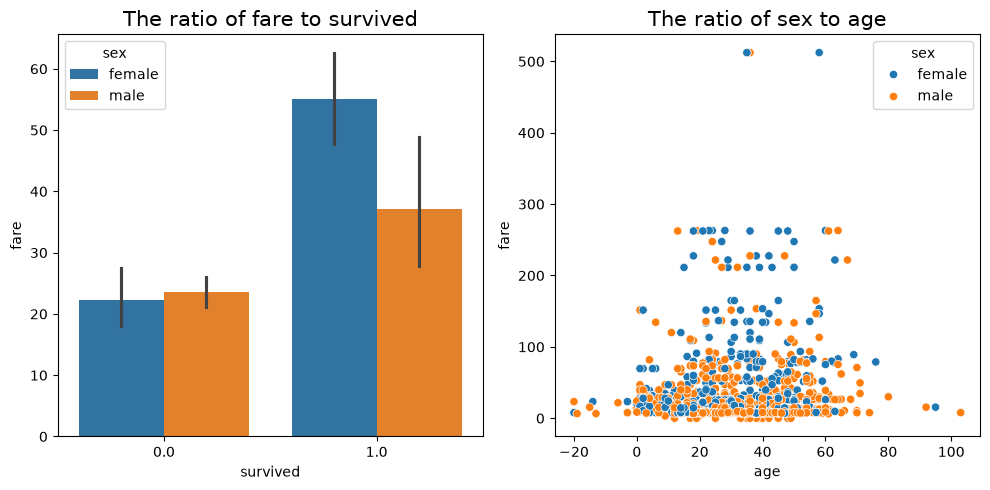

In [85]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(data=titanic, x='survived', y='fare', hue='sex', ax=axs[0])
axs[0].set_title('The ratio of fare to survived', size=15)

sns.scatterplot(data=titanic, x='age', y='fare', hue='sex', ax=axs[1])
axs[1].set_title('The ratio of sex to age', size=15)

fig.tight_layout()

In [86]:
titanic.isna().sum()

pclass         0
survived       0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           0
embarked       0
home.dest    564
dtype: int64

In [87]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   float64
 1   survived   1309 non-null   float64
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1309 non-null   float64
 5   sibsp      1309 non-null   float64
 6   parch      1309 non-null   float64
 7   ticket     1309 non-null   str    
 8   fare       1309 non-null   float64
 9   embarked   1309 non-null   str    
 10  home.dest  745 non-null    str    
dtypes: float64(6), str(5)
memory usage: 177.9 KB


In [88]:
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0,0.0,0.0,24160,211.3375,S,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,1.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON"


In [89]:
titanic['alone'] = ((titanic['sibsp'] == 0) & (titanic['parch'] == 0))
titanic['alone']

0        True
1       False
2       False
3       False
4       False
        ...  
1304    False
1305    False
1306     True
1307     True
1308     True
Name: alone, Length: 1309, dtype: bool

In [90]:
titanic['FamilySize'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['FamilySize']

0       1.0
1       4.0
2       4.0
3       4.0
4       4.0
       ... 
1304    2.0
1305    2.0
1306    1.0
1307    1.0
1308    1.0
Name: FamilySize, Length: 1309, dtype: float64

In [91]:
label = ['infant', 'toddler', 'child', 'teen', 'adult', 'middle_age', 'senior', 'old']
bin = [0, 1, 4, 12, 18, 39, 59, 74, np.inf]
titanic['age_group'] = pd.cut(titanic['age'], labels=label, bins=bin)
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,alone,FamilySize,age_group
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0,0.0,0.0,24160,211.3375,S,"St Louis, MO",True,1.0,adult
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,1.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,infant
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,toddler
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,0.0,"Zabour, Miss. Hileni",female,14.0,1.0,0.0,2665,14.4542,C,NaN,False,2.0,teen
1305,3.0,0.0,"Zabour, Miss. Thamine",female,18.0,1.0,0.0,2665,14.4542,C,NaN,False,2.0,teen
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.0,0.0,0.0,2656,7.2250,C,NaN,True,1.0,adult
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0,0.0,0.0,2670,7.2250,C,NaN,True,1.0,adult


In [92]:
titanic['NamePrefix'] = titanic['name'].str.extract(r',\s*([^.]*)\.')
titanic['name'] = titanic['name'].str.replace(r',.*?\.\s*', '', regex=True)

In [93]:
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,alone,FamilySize,age_group,NamePrefix
0,1.0,1.0,AllenElisabeth Walton,female,29.0,0.0,0.0,24160,211.3375,S,"St Louis, MO",True,1.0,adult,Miss
1,1.0,1.0,AllisonHudson Trevor,male,1.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,infant,Master
2,1.0,0.0,AllisonHelen Loraine,female,2.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,toddler,Miss
3,1.0,0.0,AllisonHudson Joshua Creighton,male,30.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mr
4,1.0,0.0,AllisonHudson J C (Bessie Waldo Daniels),female,25.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mrs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,0.0,ZabourHileni,female,14.0,1.0,0.0,2665,14.4542,C,NaN,False,2.0,teen,Miss
1305,3.0,0.0,ZabourThamine,female,18.0,1.0,0.0,2665,14.4542,C,NaN,False,2.0,teen,Miss
1306,3.0,0.0,ZakarianMapriededer,male,26.0,0.0,0.0,2656,7.2250,C,NaN,True,1.0,adult,Mr
1307,3.0,0.0,ZakarianOrtin,male,27.0,0.0,0.0,2670,7.2250,C,NaN,True,1.0,adult,Mr


In [94]:
titanic['who'] = np.select(
    [
        titanic['age'] < 16,
        titanic['sex'] == 'female'
    ],
    [
        'child',
        'woman'
    ],
    default='man'
)
titanic['who']

0       woman
1       child
2       child
3         man
4       woman
        ...  
1304    child
1305    woman
1306      man
1307      man
1308      man
Name: who, Length: 1309, dtype: str

In [95]:
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,home.dest,alone,FamilySize,age_group,NamePrefix,who
0,1.0,1.0,AllenElisabeth Walton,female,29.0,0.0,0.0,24160,211.3375,S,"St Louis, MO",True,1.0,adult,Miss,woman
1,1.0,1.0,AllisonHudson Trevor,male,1.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,infant,Master,child
2,1.0,0.0,AllisonHelen Loraine,female,2.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,toddler,Miss,child
3,1.0,0.0,AllisonHudson Joshua Creighton,male,30.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mr,man
4,1.0,0.0,AllisonHudson J C (Bessie Waldo Daniels),female,25.0,1.0,2.0,113781,151.5500,S,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mrs,woman


In [96]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   pclass      1309 non-null   float64 
 1   survived    1309 non-null   float64 
 2   name        1309 non-null   str     
 3   sex         1309 non-null   str     
 4   age         1309 non-null   float64 
 5   sibsp       1309 non-null   float64 
 6   parch       1309 non-null   float64 
 7   ticket      1309 non-null   str     
 8   fare        1309 non-null   float64 
 9   embarked    1309 non-null   str     
 10  home.dest   745 non-null    str     
 11  alone       1309 non-null   bool    
 12  FamilySize  1309 non-null   float64 
 13  age_group   1295 non-null   category
 14  NamePrefix  1309 non-null   str     
 15  who         1309 non-null   str     
dtypes: bool(1), category(1), float64(7), str(7)
memory usage: 211.3 KB


In [97]:
titanic['sex'] = titanic['sex'].astype('category')
titanic['embarked'] = titanic['embarked'].astype('category')

In [98]:
titanic = pd.get_dummies(titanic, columns=['embarked'], dtype=int)
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,home.dest,alone,FamilySize,age_group,NamePrefix,who,embarked_C,embarked_Q,embarked_S
0,1.0,1.0,AllenElisabeth Walton,female,29.0,0.0,0.0,24160,211.3375,"St Louis, MO",True,1.0,adult,Miss,woman,0,0,1
1,1.0,1.0,AllisonHudson Trevor,male,1.0,1.0,2.0,113781,151.5500,"Montreal, PQ / Chesterville, ON",False,4.0,infant,Master,child,0,0,1
2,1.0,0.0,AllisonHelen Loraine,female,2.0,1.0,2.0,113781,151.5500,"Montreal, PQ / Chesterville, ON",False,4.0,toddler,Miss,child,0,0,1
3,1.0,0.0,AllisonHudson Joshua Creighton,male,30.0,1.0,2.0,113781,151.5500,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mr,man,0,0,1
4,1.0,0.0,AllisonHudson J C (Bessie Waldo Daniels),female,25.0,1.0,2.0,113781,151.5500,"Montreal, PQ / Chesterville, ON",False,4.0,adult,Mrs,woman,0,0,1


In [99]:
titanic = titanic.drop(columns=['name', 'home.dest', 'ticket'])

In [100]:
titanic['alone'] = titanic['alone'].astype(int)

In [101]:
titanic['sex_code'] = titanic['sex'].cat.codes

In [102]:
titanic['age_group'] = pd.Categorical(
    titanic['age_group'],
    categories=['infant', 'toddler', 'child', 'teen', 'adult', 'middle_age', 'senior', 'old'],
    ordered=True
)

titanic['age_group_code'] = titanic['age_group'].cat.codes

In [103]:
titanic = pd.get_dummies(
    titanic,
    columns=['who'],
    dtype=int
)

In [104]:
titanic['NamePrefix'].value_counts()

NamePrefix
Mr              757
Miss            260
Mrs             197
Master           61
Dr                8
Rev               8
Col               4
Major             2
Mlle              2
Ms                2
Mme               1
Capt              1
Lady              1
Sir               1
Dona              1
Jonkheer          1
the Countess      1
Don               1
Name: count, dtype: int64

In [105]:
rare_titles = [
    'Dona', 'Lady', 'Mme', 'the Countess',
    'Jonkheer', 'Mlle', 'Don', 'Capt',
    'Sir', 'Ms', 'Major', 'Col', 'Dr', 'Rev'
]

titanic['NamePrefix'] = titanic['NamePrefix'].replace(
    rare_titles,
    'Rare'
)

In [106]:
titanic = pd.get_dummies(
    titanic,
    columns=['NamePrefix'],
    dtype=int
)

In [107]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   pclass             1309 non-null   float64 
 1   survived           1309 non-null   float64 
 2   sex                1309 non-null   category
 3   age                1309 non-null   float64 
 4   sibsp              1309 non-null   float64 
 5   parch              1309 non-null   float64 
 6   fare               1309 non-null   float64 
 7   alone              1309 non-null   int64   
 8   FamilySize         1309 non-null   float64 
 9   age_group          1295 non-null   category
 10  embarked_C         1309 non-null   int64   
 11  embarked_Q         1309 non-null   int64   
 12  embarked_S         1309 non-null   int64   
 13  sex_code           1309 non-null   int8    
 14  age_group_code     1309 non-null   int8    
 15  who_child          1309 non-null   int64   
 16  who_man          

In [108]:
titanic.head()

,pclass,survived,sex,age,sibsp,parch,fare,alone,FamilySize,age_group,...,sex_code,age_group_code,who_child,who_man,who_woman,NamePrefix_Master,NamePrefix_Miss,NamePrefix_Mr,NamePrefix_Mrs,NamePrefix_Rare
0,1.0,1.0,female,29.0,0.0,0.0,211.3375,1,1.0,adult,...,0,4,0,0,1,0,1,0,0,0
1,1.0,1.0,male,1.0,1.0,2.0,151.5500,0,4.0,infant,...,1,0,1,0,0,1,0,0,0,0
2,1.0,0.0,female,2.0,1.0,2.0,151.5500,0,4.0,toddler,...,0,1,1,0,0,0,1,0,0,0
3,1.0,0.0,male,30.0,1.0,2.0,151.5500,0,4.0,adult,...,1,4,0,1,0,0,0,1,0,0
4,1.0,0.0,female,25.0,1.0,2.0,151.5500,0,4.0,adult,...,0,4,0,0,1,0,0,0,1,0


In [109]:
abs(titanic.corr(numeric_only=True)['survived']).sort_values(ascending=False)

survived             1.000000
NamePrefix_Mr        0.529016
sex_code             0.528693
who_man              0.516781
who_woman            0.485052
NamePrefix_Mrs       0.350699
pclass               0.312469
NamePrefix_Miss      0.302225
fare                 0.244414
alone                0.201719
embarked_C           0.182123
embarked_S           0.150542
who_child            0.100251
age_group_code       0.095977
parch                0.082660
age                  0.058444
NamePrefix_Master    0.057436
sibsp                0.027825
FamilySize           0.026876
NamePrefix_Rare      0.019899
embarked_Q           0.016071
Name: survived, dtype: float64

In [110]:
X = titanic.select_dtypes(include=['float', 'int'])
X = X.drop(columns='survived')
y = titanic['survived']

In [111]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100)

forest.fit(X, y)
forest_important = forest.feature_importances_

In [112]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3, max_leaf_nodes=50)

tree.fit(X, y)
tree_important = tree.feature_importances_

In [113]:
pd.concat([
    pd.Series(forest_important, name='forest_important'),
    pd.Series(tree_important, name='tree_important'),
    pd.Series(X.columns, name='columns')
], axis=1).sort_values(['tree_important', 'forest_important'], ascending=False)

,forest_important,tree_important,columns
15,0.100289,0.624946,NamePrefix_Mr
0,0.074707,0.203047,pclass
4,0.241415,0.076937,fare
11,0.090928,0.071086,who_man
1,0.228305,0.023984,age
12,0.067293,0.000000,who_woman
6,0.043895,0.000000,FamilySize
2,0.029026,0.000000,sibsp
14,0.027204,0.000000,NamePrefix_Miss
3,0.018044,0.000000,parch


In [114]:
X_new = X.drop(columns=['NamePrefix_Rare', 'embarked_Q', 'NamePrefix_Master', 'who_child', 'alone', 'parch'])

In [115]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [116]:
# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

In [117]:
# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [118]:
X_tarin, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [119]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

standard_scale = StandardScaler()
minmax_scale = MinMaxScaler()

In [120]:
X_train_scaled = standard_scale.fit_transform(X_tarin)
X_test_scaled = standard_scale.transform(X_test)

In [121]:
from utils import evaluate, plot_confusion_matrix

# Logistic Regression

In [122]:
logistic = LogisticRegression(max_iter=1000)

logistic.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [123]:
y_pred_log = logistic.predict(X_test_scaled)

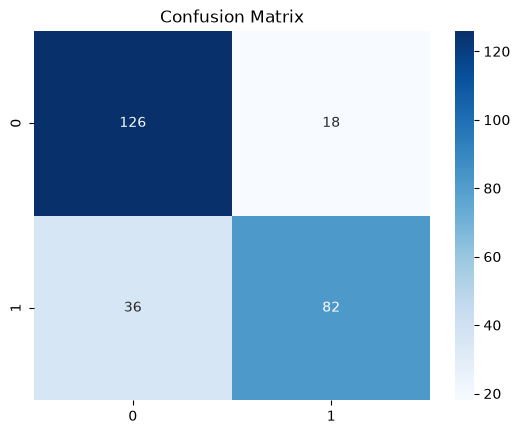

In [124]:
plot_confusion_matrix(logistic, X_test_scaled, y_test)

In [125]:
evaluate(logistic, X_test_scaled, y_test)

{'Accuracy': 0.7938931297709924,
 'Precision': 0.82,
 'Recall': 0.6949152542372882,
 'F1 Score': 0.7522935779816514,
 'ROC-AUC': 0.8617290489642184}

# KNeighbors Classifier

In [126]:
knn = KNeighborsClassifier(n_neighbors=5, weights='uniform')

knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [127]:
y_pred_knn = knn.predict(X_test_scaled)

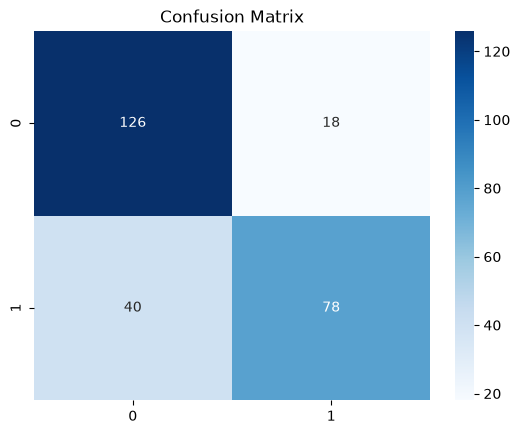

In [128]:
plot_confusion_matrix(knn, X_test_scaled, y_test)

In [129]:
evaluate(knn, X_test_scaled, y_test)

{'Accuracy': 0.7786259541984732,
 'Precision': 0.8125,
 'Recall': 0.6610169491525424,
 'F1 Score': 0.7289719626168224,
 'ROC-AUC': 0.8252118644067796}

# DecisionTree Classifier

In [130]:
tree = DecisionTreeClassifier(max_depth=5, max_leaf_nodes=5)

tree.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

In [131]:
y_pred_tree = tree.predict(X_test_scaled)

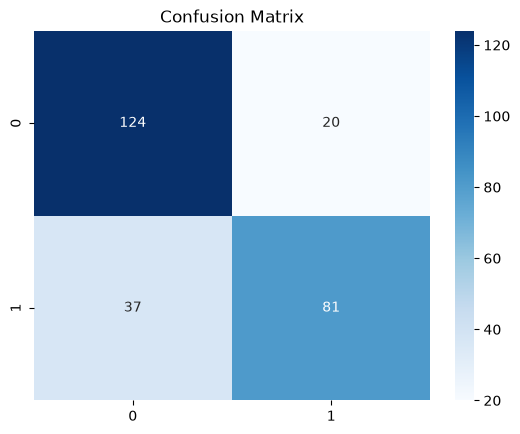

In [132]:
plot_confusion_matrix(tree, X_test_scaled, y_test)

In [133]:
evaluate(tree, X_test_scaled, y_test)

{'Accuracy': 0.7824427480916031,
 'Precision': 0.801980198019802,
 'Recall': 0.6864406779661016,
 'F1 Score': 0.7397260273972602,
 'ROC-AUC': 0.8049376177024481}

# RandomForest Classifier

In [134]:
forest = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1)

forest.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [135]:
y_pred_forest = forest.predict(X_test_scaled)

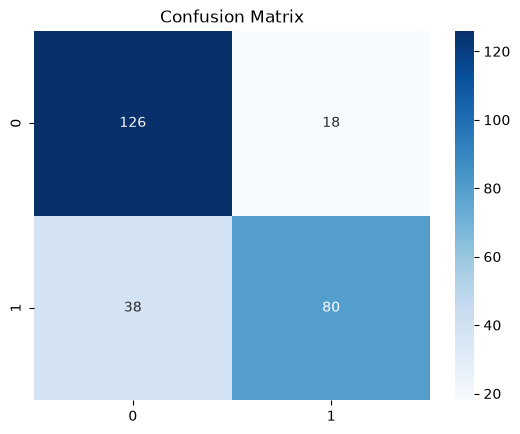

In [136]:
plot_confusion_matrix(forest, X_test_scaled, y_test)

In [137]:
evaluate(forest, X_test_scaled, y_test)

{'Accuracy': 0.7862595419847328,
 'Precision': 0.8163265306122449,
 'Recall': 0.6779661016949152,
 'F1 Score': 0.7407407407407407,
 'ROC-AUC': 0.8546963276836157}

# GradientBoosting Classifier

In [138]:
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)

gb.fit(X_train_scaled, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [139]:
y_pred_gb = gb.predict(X_test_scaled)

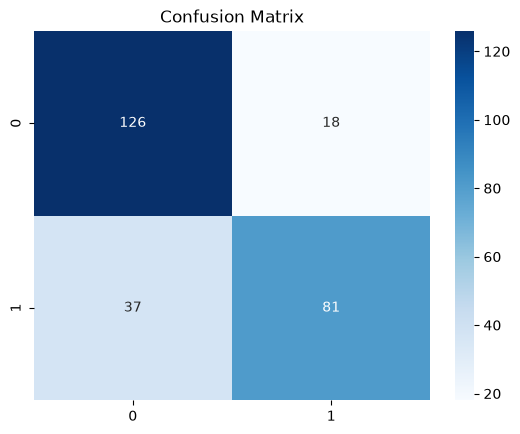

In [140]:
plot_confusion_matrix(gb, X_test_scaled, y_test)

In [141]:
evaluate(gb, X_test_scaled, y_test)

{'Accuracy': 0.7900763358778626,
 'Precision': 0.8181818181818182,
 'Recall': 0.6864406779661016,
 'F1 Score': 0.7465437788018433,
 'ROC-AUC': 0.8608168549905838}

# Support Vector Machine

In [142]:
svm = SVC(
    C=1.0,
    kernel="rbf",
    gamma="scale",
    probability=True,
    random_state=42
)

svm.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [143]:
y_pred_svm = svm.predict(X_test_scaled)

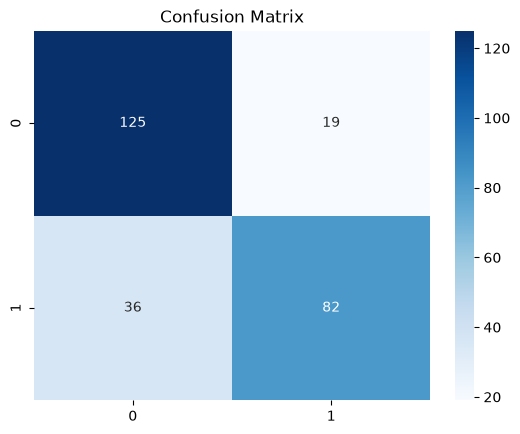

In [144]:
plot_confusion_matrix(svm, X_test_scaled, y_test)

In [145]:
evaluate(svm, X_test_scaled, y_test)

{'Accuracy': 0.7900763358778626,
 'Precision': 0.8118811881188119,
 'Recall': 0.6949152542372882,
 'F1 Score': 0.7488584474885844,
 'ROC-AUC': 0.8240936911487758}

# naive gaussiannb model

In [146]:
naive = GaussianNB()

naive.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [147]:
y_pred_naive = naive.predict(X_test_scaled)

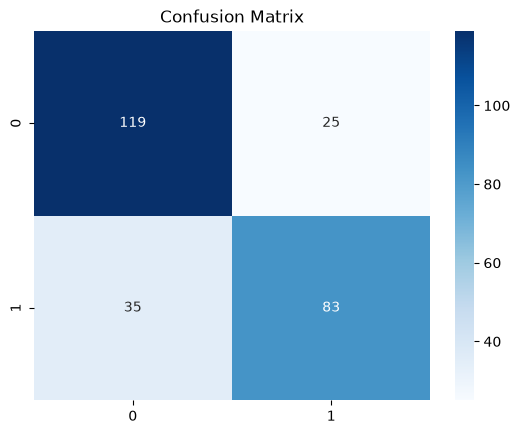

In [148]:
plot_confusion_matrix(naive, X_test_scaled, y_test)

In [149]:
evaluate(naive, X_test_scaled, y_test)

{'Accuracy': 0.7709923664122137,
 'Precision': 0.7685185185185185,
 'Recall': 0.7033898305084746,
 'F1 Score': 0.7345132743362832,
 'ROC-AUC': 0.8329508003766477}

# cross val score

In [150]:
# logistic
cross_log = cross_val_score(
    logistic,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)
print('cross_val_score logistic:\n')
print(cross_log)
print(f'mean: {cross_log.mean()}')
print(f'std: {cross_log.std()}')

cross_val_score logistic:

[0.80536913 0.72483221 0.78145695 0.69798658 0.67114094]
mean: 0.7361571625405573
std: 0.05030849718355007


In [151]:
# knn
cross_knn = cross_val_score(
    knn,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)
print('cross_val_score KNN:\n')
print(cross_knn)
print(f'mean: {cross_log.mean()}')
print(f'std: {cross_log.std()}')

cross_val_score KNN:

[0.74647887 0.65333333 0.75       0.71830986 0.65734266]
mean: 0.7361571625405573
std: 0.05030849718355007


In [152]:
# tree
cross_tree = cross_val_score(
    tree,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)
print('cross_val_score tree:\n')
print(cross_tree)
print(f'mean: {cross_log.mean()}')
print(f'std: {cross_log.std()}')

cross_val_score tree:

[0.8        0.75496689 0.79738562 0.73825503 0.67567568]
mean: 0.7361571625405573
std: 0.05030849718355007


In [153]:
# forest
cross_forest = cross_val_score(
    forest,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)
print('cross_val_score forest:\n')
print(cross_forest)
print(f'mean: {cross_log.mean()}')
print(f'std: {cross_log.std()}')

cross_val_score forest:

[0.78873239 0.67625899 0.73103448 0.74829932 0.67549669]
mean: 0.7361571625405573
std: 0.05030849718355007


In [154]:
# gradientboost
cross_gb = cross_val_score(
    gb,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)
print('cross_val_score gradientboost:\n')
print(cross_gb)
print(f'mean: {cross_log.mean()}')
print(f'std: {cross_log.std()}')

cross_val_score gradientboost:

[0.75362319 0.71014493 0.71328671 0.75177305 0.68055556]
mean: 0.7361571625405573
std: 0.05030849718355007


In [155]:
# svm
cross_svm = cross_val_score(
    svm,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)
print('cross_val_score svm:\n')
print(cross_svm)
print(f'mean: {cross_log.mean()}')
print(f'std: {cross_log.std()}')

cross_val_score svm:

[0.80794702 0.72727273 0.73972603 0.71724138 0.67567568]
mean: 0.7361571625405573
std: 0.05030849718355007


In [156]:
# naivebase
cross_naive = cross_val_score(
    naive,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)
print('cross_val_score naive:\n')
print(cross_naive)
print(f'mean: {cross_log.mean()}')
print(f'std: {cross_log.std()}')

cross_val_score naive:

[0.77108434 0.71165644 0.7721519  0.70967742 0.65030675]
mean: 0.7361571625405573
std: 0.05030849718355007


In [157]:
cross = pd.DataFrame({
    'logistic': cross_log,
    'knn': cross_knn,
    'tree': cross_tree,
    'forest': cross_forest,
    'gb': cross_gb,
    'svm': cross_svm,
    'naive': cross_naive
})
cross

,logistic,knn,tree,forest,gb,svm,naive
0,0.805369,0.746479,0.800000,0.788732,0.753623,0.807947,0.771084
1,0.724832,0.653333,0.754967,0.676259,0.710145,0.727273,0.711656
2,0.781457,0.750000,0.797386,0.731034,0.713287,0.739726,0.772152
3,0.697987,0.718310,0.738255,0.748299,0.751773,0.717241,0.709677
4,0.671141,0.657343,0.675676,0.675497,0.680556,0.675676,0.650307


In [158]:
cross.describe()

,logistic,knn,tree,forest,gb,svm,naive
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.736157,0.705093,0.753257,0.723964,0.721877,0.733573,0.722975
std,0.056247,0.047072,0.050939,0.048636,0.030905,0.048031,0.050790
min,0.671141,0.653333,0.675676,0.675497,0.680556,0.675676,0.650307
25%,0.697987,0.657343,0.738255,0.676259,0.710145,0.717241,0.709677
50%,0.724832,0.718310,0.754967,0.731034,0.713287,0.727273,0.711656
75%,0.781457,0.746479,0.797386,0.748299,0.751773,0.739726,0.771084
max,0.805369,0.750000,0.800000,0.788732,0.753623,0.807947,0.772152


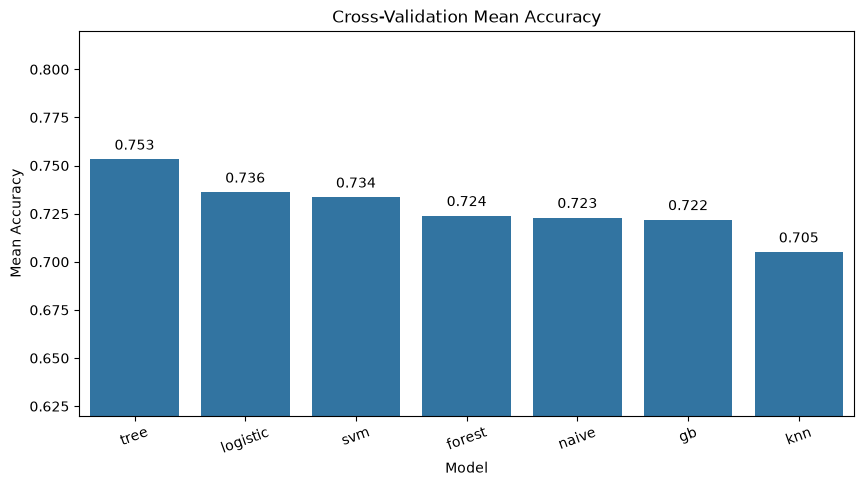

In [159]:
cross_mean = cross.mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=cross_mean.index,
    y=cross_mean.values
)

for i, value in enumerate(cross_mean.values):
    plt.text(i, value + 0.005, f"{value:.3f}", ha="center")

plt.title("Cross-Validation Mean Accuracy")
plt.xlabel("Model")
plt.ylabel("Mean Accuracy")

plt.xticks(rotation=20)
plt.ylim((0.62, 0.82))
plt.show()

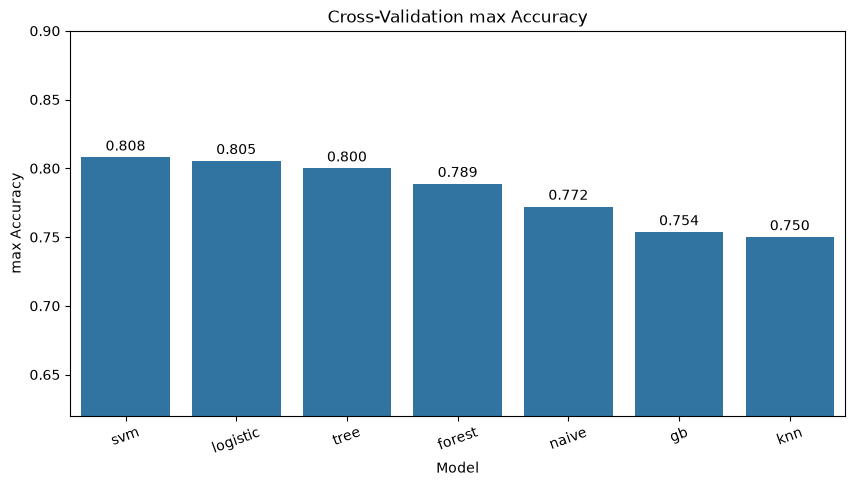

In [160]:
cross_max = cross.max().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=cross_max.index,
    y=cross_max.values
)

for i, value in enumerate(cross_max.values):
    plt.text(i, value + 0.005, f"{value:.3f}", ha="center")

plt.title("Cross-Validation max Accuracy")
plt.xlabel("Model")
plt.ylabel("max Accuracy")

plt.xticks(rotation=20)
plt.ylim((0.62, 0.90))
plt.show()

# GridSearchCV

In [161]:
param_logistic = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

param_knn = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

param_tree = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

param_forest = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

param_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

param_svm = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

param_naive = {
    "var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

In [162]:
grid_logistic = GridSearchCV(
    logistic,
    param_logistic,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_logistic.fit(X_train_scaled, y_train)

print(grid_logistic.best_score_)
print(grid_logistic.best_params_)
print(grid_logistic.best_estimator_)

0.7413869695664951
{'C': 0.1, 'solver': 'liblinear'}
LogisticRegression(C=0.1, max_iter=1000, solver='liblinear')


In [163]:
grid_knn = GridSearchCV(
    knn,
    param_knn,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

print(grid_knn.best_params_)
print(grid_knn.best_score_)
print(grid_knn.best_estimator_)

{'n_neighbors': 11, 'p': 2, 'weights': 'uniform'}
0.7141440789716651
KNeighborsClassifier(n_neighbors=11)


In [164]:
grid_tree = GridSearchCV(
    tree,
    param_tree,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_tree.fit(X_train_scaled, y_train)

print(grid_tree.best_score_)
print(grid_tree.best_params_)
print(grid_tree.best_estimator_)

0.7547895818190249
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
DecisionTreeClassifier(max_depth=3, max_leaf_nodes=5)


In [165]:
grid_forest = GridSearchCV(
    forest,
    param_forest,
    cv=4,
    scoring="f1",
    n_jobs=-1
)

grid_forest.fit(X_train_scaled, y_train)

print(grid_forest.best_score_)
print(grid_forest.best_params_)
print(grid_forest.best_estimator_)

0.7501803023574188
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
RandomForestClassifier(max_depth=3, min_samples_split=5, n_estimators=200,
                       n_jobs=-1, random_state=42)


In [166]:
grid_gb = GridSearchCV(
    gb,
    param_gb,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_gb.fit(X_train_scaled, y_train)

print(grid_gb.best_score_)
print(grid_gb.best_params_)
print(grid_gb.best_estimator_)

0.7289716425029791
{'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
GradientBoostingClassifier(learning_rate=0.05, max_depth=5, random_state=42)


In [167]:
grid_svm = GridSearchCV(
    svm,
    param_svm,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

print(grid_svm.best_score_)
print(grid_svm.best_params_)
print(grid_svm.best_estimator_)

0.7342271948039014
{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
SVC(C=0.1, kernel='linear', probability=True, random_state=42)


In [168]:
grid_naive = GridSearchCV(
    naive,
    param_naive,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_naive.fit(X_train_scaled, y_train)

print(grid_naive.best_score_)
print(grid_naive.best_params_)
print(grid_naive.best_estimator_)

0.7229753691244925
{'var_smoothing': 1e-11}
GaussianNB(var_smoothing=1e-11)


In [169]:
grid_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVM",
        "Naive Bayes"
    ],
    "Best CV Score": [
        grid_logistic.best_score_,
        grid_knn.best_score_,
        grid_tree.best_score_,
        grid_forest.best_score_,
        grid_gb.best_score_,
        grid_svm.best_score_,
        grid_naive.best_score_
    ]
})

grid_results.sort_values('Best CV Score',ascending=False)

,Model,Best CV Score
2,Decision Tree,0.754790
3,Random Forest,0.750180
0,Logistic Regression,0.741387
5,SVM,0.734227
4,Gradient Boosting,0.728972
6,Naive Bayes,0.722975
1,KNN,0.714144


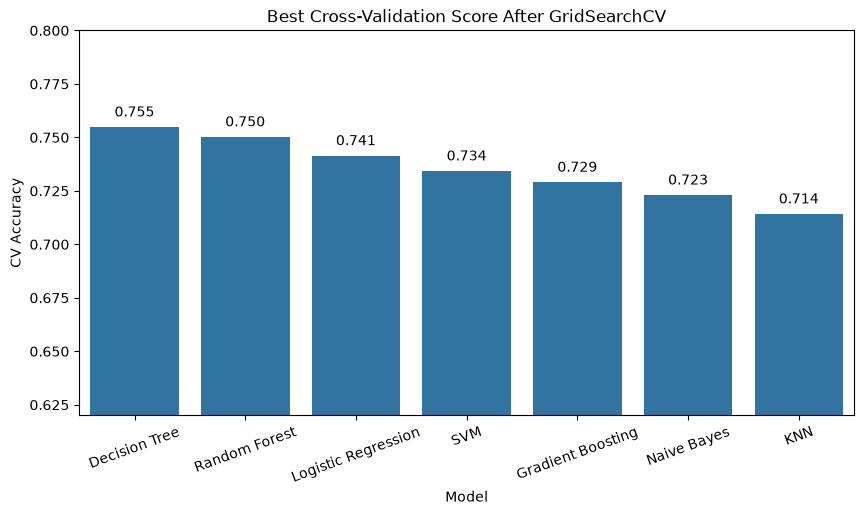

In [170]:
grid_results = grid_results.sort_values('Best CV Score',ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=grid_results,
    x="Model",
    y="Best CV Score"
)

plt.title("Best Cross-Validation Score After GridSearchCV")
plt.xlabel("Model")
plt.ylabel("CV Accuracy")

plt.xticks(rotation=20)

for i, value in enumerate(grid_results["Best CV Score"]):
    plt.text(i, value + 0.005, f"{value:.3f}", ha="center")

plt.ylim((0.62, 0.80))
plt.show()

# Final evaluation

In [171]:
grid_results.sort_values('Best CV Score',ascending=False)

,Model,Best CV Score
2,Decision Tree,0.754790
3,Random Forest,0.750180
0,Logistic Regression,0.741387
5,SVM,0.734227
4,Gradient Boosting,0.728972
6,Naive Bayes,0.722975
1,KNN,0.714144


In [172]:
results = pd.DataFrame({
    "Model": cross.columns,
    "Mean Cross Validation": cross.mean().values,
    "GridSearchCV": [
        grid_logistic.best_score_,
        grid_knn.best_score_,
        grid_tree.best_score_,
        grid_forest.best_score_,
        grid_gb.best_score_,
        grid_svm.best_score_,
        grid_naive.best_score_
    ]
})

results = results.sort_values(
    "GridSearchCV",
    ascending=False
).reset_index(drop=True)

results

,Model,Mean Cross Validation,GridSearchCV
0,tree,0.753257,0.754790
1,forest,0.723964,0.750180
2,logistic,0.736157,0.741387
3,svm,0.733573,0.734227
4,gb,0.721877,0.728972
5,naive,0.722975,0.722975
6,knn,0.705093,0.714144


In [173]:
results_test = pd.DataFrame({
    "Model": [
        "tree",
        "forest",
        "logistic",
        "svm",
        "gb",
        "naive",
        "knn"
    ],
    "Test Accuracy": [
        accuracy_score(y_test, grid_tree.best_estimator_.predict(X_test_scaled)),
        accuracy_score(y_test, grid_forest.best_estimator_.predict(X_test_scaled)),
        accuracy_score(y_test, grid_logistic.best_estimator_.predict(X_test_scaled)),
        accuracy_score(y_test, grid_svm.best_estimator_.predict(X_test_scaled)),
        accuracy_score(y_test, grid_gb.best_estimator_.predict(X_test_scaled)),
        accuracy_score(y_test, grid_naive.best_estimator_.predict(X_test)),
        accuracy_score(y_test, grid_knn.best_estimator_.predict(X_test_scaled))
    ]
})

results_test.sort_values("Test Accuracy", ascending=False)

C:\Users\AlmasRayan\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


,Model,Test Accuracy
2,logistic,0.790076
1,forest,0.786260
0,tree,0.782443
4,gb,0.782443
3,svm,0.774809
6,knn,0.770992
5,naive,0.450382


In [ ]:
import os

os.makedirs("models", exist_ok=True)

In [176]:
import joblib

joblib.dump(
    grid_logistic.best_estimator_,
    "models/logistic_model.pkl"
)

['models/logistic_model.pkl']